# 04 · Results, Analysis & Conclusions
Report sections: *Results* + *Analysis*. Loads the per-notebook result CSVs (no model refit here) and assembles the consolidated comparison + the DR ablation.

In [1]:
import sys, os; sys.path.insert(0, os.path.abspath('..'))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.data.pipeline import build_dataset
from src.data.odds import method_market
from src.metrics import collapse_winner
from src.plotting import save_fig

## 1. Consolidated comparison (Luka)
Baselines (02) + SAMME (03) + naive + market, all on the original-corner test.

In [2]:
base = pd.read_csv('../report/results_baselines.csv', index_col='model')
ext = pd.read_csv('../report/results_extension.csv', index_col='model')
table = pd.concat([base, ext])
# reference points (cheap, no model fit): always-red winner-rate + coin flip
ds = build_dataset(seed=0)
ar = (collapse_winner(ds.y_test.values) == 'Red').mean()
print(f'always-red winner = {ar:.3f}   coin-flip = 0.500')
table.round(3)

always-red winner = 0.562   coin-flip = 0.500


,acc6_mean,acc6_std,winner_mean,winner_std,method_mean,logloss_mean
model,,,,,,
LDA,0.343,0.004,0.626,0.004,0.516,1.592
QDA,0.230,0.018,0.567,0.029,0.371,3.134
kNN (k=15),0.282,0.004,0.550,0.006,0.497,3.642
majority,0.266,0.025,0.521,0.059,0.514,1.702
SAMME,0.349,0.012,0.633,0.016,0.515,1.663


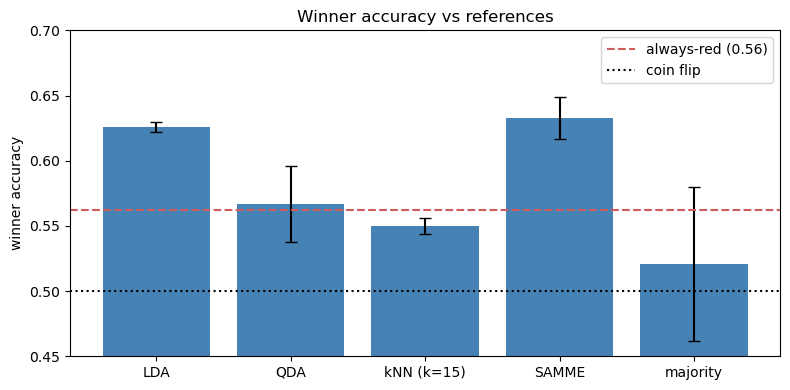

In [3]:
# winner-accuracy comparison with error bars (the headline results figure)
order = ['LDA','QDA','kNN (k=15)','SAMME','majority']
order = [m for m in order if m in table.index]
means = table.loc[order,'winner_mean']; stds = table.loc[order,'winner_std'].fillna(0)
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(order, means, yerr=stds, capsize=4, color='steelblue')
ax.axhline(ar, ls='--', c='indianred', label=f'always-red ({ar:.2f})')
ax.axhline(0.5, ls=':', c='k', label='coin flip')
ax.set_ylabel('winner accuracy'); ax.set_ylim(0.45, 0.7); ax.legend(); ax.set_title('Winner accuracy vs references')
plt.tight_layout(); save_fig('model_comparison'); plt.show()

## 2. Dimensionality-reduction ablation (E3)
**(Milica, issue #15)** Does PCA / LDA-projection help QDA/kNN (weak in ~114 dims)?

In [4]:
# E3 (Milica, issue #15): DR ablation.
# - from src.baselines import PCA, LDAProjection
# - pick PCA dims via the explained-variance curve (course 09_pca) and/or sweep d
# - refit ALL models on the reduced features; compare to the full-feature table above
# - 2D PCA scatter coloured by class -> save_fig('pca_2d')
# TODO(Milica): does DR rescue QDA/kNN?

## 3. Discussion & conclusions
Key findings: best models reach ~0.36 six-class / ~0.63 winner; SAMME ties LDA (the extra complexity does not pay off here); the market still edges us on log-loss (1.55 vs ~1.66) but we are close to the ceiling; QDA/kNN suffer in high dimensions (regularization helps log-loss, DR is the next lever). TODO(Luka): write up against §7/§8.